In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
# Install needed packages
!pip install h5py rasterio folium

import os
import h5py
import random
import pandas as pd
import numpy as np
import folium
import matplotlib.pyplot as plt

Selected Fire: fire_24332622 from 2020
Selected Day Index: 0 (out of 29)


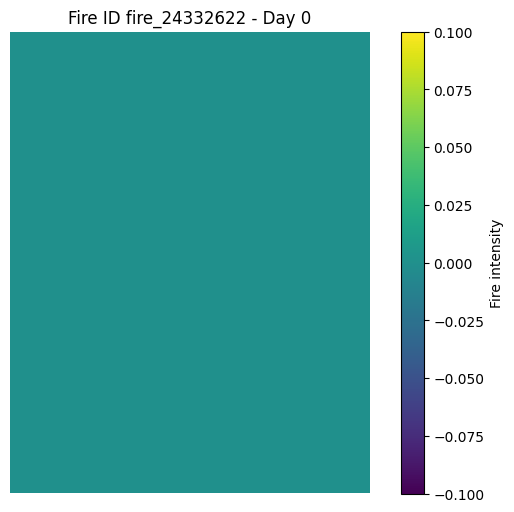

Bounding Box: (39.82347712869651, -121.25312725718432) to (40.822503952929125, -120.18225915939084)
✅ Map saved at /content/random_fire_map.html


In [178]:


# Paths
hdf5_root = '/content/drive/MyDrive/Wildfire Spread Prevention Project/wildfirespreadts/hdf5'
locations_csv = '/content/drive/MyDrive/Wildfire Spread Prevention Project/fire_event_locations_final.csv'  # Corrected

# Load fire locations CSV
locations_df = pd.read_csv(locations_csv)

# Pick random year and fire
year = random.choice(['2018', '2019', '2020', '2021'])
year_dir = os.path.join(hdf5_root, year)
fire_files = [f for f in os.listdir(year_dir) if f.endswith('.hdf5')]

# Pick a random HDF5 file
random_fire_file = random.choice(fire_files)
random_fire_id = random_fire_file.replace('.hdf5', '')
fire_path = os.path.join(year_dir, random_fire_file)

print(f"Selected Fire: {random_fire_id} from {year}")

# Open HDF5 and pick random time index
with h5py.File(fire_path, 'r') as f:
    data = f['data']
    num_timesteps = data.shape[0]
    random_day_idx = random.randint(0, num_timesteps - 1)

    print(f"Selected Day Index: {random_day_idx} (out of {num_timesteps})")

    # Assume fire channel is 22
    fire_mask = data[random_day_idx, 22, :, :]  # fire mask

# ✅ Display the Fire Mask Image using VIRIDIS (as we always did)
plt.figure(figsize=(8, 6))
plt.imshow(fire_mask, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Fire intensity')
plt.title(f'Fire ID {random_fire_id} - Day {random_day_idx}')
plt.axis('off')
plt.show()

# Find corresponding bounding box
fire_location = locations_df[locations_df['fire_id'] == random_fire_id]

if fire_location.empty:
    print(f"No location found for {random_fire_id}")
else:
    lat_min = fire_location.iloc[0]['lat_min']
    lat_max = fire_location.iloc[0]['lat_max']
    lon_min = fire_location.iloc[0]['lon_min']
    lon_max = fire_location.iloc[0]['lon_max']

    print(f"Bounding Box: ({lat_min}, {lon_min}) to ({lat_max}, {lon_max})")

    # Center of bounding box
    center_lat = (lat_min + lat_max) / 2
    center_lon = (lon_min + lon_max) / 2

    # Create map
    m = folium.Map(location=[center_lat, center_lon], zoom_start=9)

    # Normalize fire mask to 0 and 1 for map overlay
    fire_mask_norm = np.where(fire_mask > 0, 1, 0)

    # Save normalized mask using viridis colormap for overlay
    plt.imsave('/content/temp_fire_mask.png', fire_mask_norm, cmap='viridis')

    # Overlay on map
    fire_image = folium.raster_layers.ImageOverlay(
        name='Fire Mask',
        image='/content/temp_fire_mask.png',
        bounds=[[lat_min, lon_min], [lat_max, lon_max]],
        opacity=0.6,
        interactive=True,
        cross_origin=False,
        zindex=1,
    )
    fire_image.add_to(m)

    folium.LayerControl().add_to(m)

    # Save and display map
    m.save('/content/random_fire_map.html')
    print("✅ Map saved at /content/random_fire_map.html")

    m

In [138]:
import folium

usa_map = folium.Map(location=[39.5, -98.35], zoom_start=4)

folium.Marker(
    location=[center_lat, center_lon],
    popup=f'Fire ID: {random_fire_id}\nLat: {center_lat:.2f}, Lon: {center_lon:.2f}',
    icon=folium.Icon(color='red', icon='fire')
).add_to(usa_map)

# Save and show
usa_map.save('/content/random_fire_us_location.html')
print("✅ USA location map saved at /content/random_fire_us_location.html")

usa_map

✅ USA location map saved at /content/random_fire_us_location.html


Large Fires specifically. Or rather burst fires

Selected Fire: fire_21890072 from 2018
Selected Day Index: 6


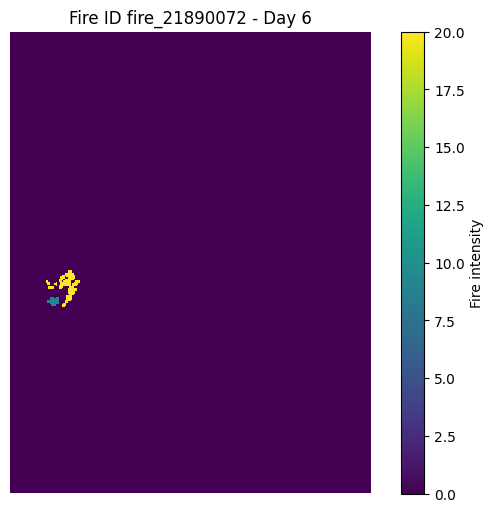

Bounding Box: (41.10107435069037, -117.58566518990948) to (42.09519968041492, -116.3958095487809)
✅ USA location map saved at /content/random_fire_us_location.html
✅ Full fire overlay map saved at /content/random_fire_map.html


In [213]:

# Paths
hdf5_root = '/content/drive/MyDrive/Wildfire Spread Prevention Project/wildfirespreadts/hdf5'
locations_csv = '/content/drive/MyDrive/Wildfire Spread Prevention Project/fire_event_locations_final.csv'
top_fires_csv = '/content/drive/MyDrive/Wildfire Spread Prevention Project/top_fire_growth_events.csv'  # new file

# Load fire locations
locations_df = pd.read_csv(locations_csv)

# Load top fire growth events
top_fires_df = pd.read_csv(top_fires_csv)

# Pick a random fire from the top fires list
random_row = top_fires_df.sample(n=1).iloc[0]
year = str(random_row['year'])
fire_file_name = random_row['file_name']
random_day_idx = int(random_row['time_step'])

random_fire_id = fire_file_name.replace('.hdf5', '')
fire_path = os.path.join(hdf5_root, year, fire_file_name)

print(f"Selected Fire: {random_fire_id} from {year}")
print(f"Selected Day Index: {random_day_idx}")

# Open the HDF5 and load the fire mask
with h5py.File(fire_path, 'r') as f:
    data = f['data']
    fire_mask = data[random_day_idx, 22, :, :]  # channel 22 is fire mask

# ✅ Display the Fire Mask Image using VIRIDIS (our normal)
plt.figure(figsize=(8, 6))
plt.imshow(fire_mask, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Fire intensity')
plt.title(f'Fire ID {random_fire_id} - Day {random_day_idx}')
plt.axis('off')
plt.show()

# Find corresponding bounding box
fire_location = locations_df[locations_df['fire_id'] == random_fire_id]

if fire_location.empty:
    print(f"No location found for {random_fire_id}")
else:
    lat_min = fire_location.iloc[0]['lat_min']
    lat_max = fire_location.iloc[0]['lat_max']
    lon_min = fire_location.iloc[0]['lon_min']
    lon_max = fire_location.iloc[0]['lon_max']

    print(f"Bounding Box: ({lat_min}, {lon_min}) to ({lat_max}, {lon_max})")

    # Center of bounding box
    center_lat = (lat_min + lat_max) / 2
    center_lon = (lon_min + lon_max) / 2

    # 🌎 Plot simple marker on USA map
    usa_map = folium.Map(location=[39.5, -98.35], zoom_start=4)
    folium.Marker(
        location=[center_lat, center_lon],
        popup=f'Fire ID: {random_fire_id}\nLat: {center_lat:.2f}, Lon: {center_lon:.2f}',
        icon=folium.Icon(color='red', icon='fire')
    ).add_to(usa_map)
    usa_map.save('/content/random_fire_us_location.html')
    print("✅ USA location map saved at /content/random_fire_us_location.html")

    # 🌎 Full fire mask overlay map
    fire_mask_norm = np.where(fire_mask > 0, 1, 0)
    plt.imsave('/content/temp_fire_mask.png', fire_mask_norm, cmap='viridis')

    fire_map = folium.Map(location=[center_lat, center_lon], zoom_start=9)
    fire_image = folium.raster_layers.ImageOverlay(
        name='Fire Mask',
        image='/content/temp_fire_mask.png',
        bounds=[[lat_min, lon_min], [lat_max, lon_max]],
        opacity=0.6,
        interactive=True,
        cross_origin=False,
        zindex=1,
    )
    fire_image.add_to(fire_map)
    folium.LayerControl().add_to(fire_map)
    fire_map.save('/content/random_fire_map.html')
    print("✅ Full fire overlay map saved at /content/random_fire_map.html")

    # Show USA map inside notebook (optional)
    usa_map

In [214]:
import folium

usa_map = folium.Map(location=[39.5, -98.35], zoom_start=4)

folium.Marker(
    location=[center_lat, center_lon],
    popup=f'Fire ID: {random_fire_id}\nLat: {center_lat:.2f}, Lon: {center_lon:.2f}',
    icon=folium.Icon(color='red', icon='fire')
).add_to(usa_map)

# Save and show
usa_map.save('/content/random_fire_us_location.html')
print("✅ USA location map saved at /content/random_fire_us_location.html")

usa_map

✅ USA location map saved at /content/random_fire_us_location.html
